# Thermodynamic parameter Plots for Schofield Paper

Can we obtain the same values reported by Scholfield? I hope so. And we can dosument the math so that others can follow our steps exactly.

I'm also going to try to make a program that will automate making all the Erying plots from the collection in the data set. Can I deterct how many substituents have data for an Erying plot and then plot separate the data? I'll have to learn some things. I enjoy learning new things. Lets go!

## Arrhenius Plot

In the Schofield paper(1), in Table is reported rate vs temperature data for rearrangements a series of substituted acetophenone oximes. Arrhenius parameters are reported: the pre-exponential factor as $\log{A}$ and the activation energy, $E_a$, in kcal/mole. Errors are given as $\pm\,0.5$ for $\log{A}$ and $\pm\,0.7$ kcal/mole for $E_a$.

### Data

The data is collected in a file: "data/Table1and2All.csv"

This file contains temp, acid conc and rate data for o,m and p-substituted acetophenone oximes. 

### Reproducing the Plot

I will reproduce the Arrhenius plots and see if my results match those presented in Table 1 of the paper. I will also obtain the errors and will compare these to those reported by the authors. 

(1) "Kinetics and mechanism of the Beckmann rearrangement of acetophenone oximes in sulphuric acid." Gregory, B. J., Moodie, R. B., & Schofield, K., *Journal of the Chemical Society B: Physical Organic*, **1970**, 338-346. https://doi.org/10.1039/j29700000338 


In [35]:
# Generic Setup
# Imports and file locations
# 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import uncertainties as unc
from uncertainties import unumpy as unp
import lmfit

github = False

if github == True:
    github_location = "https://raw.githubusercontent.com/blinkletter/4410PythonNotebooks/main/Class_21/data/"
    github_location_styles = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/styles/"
    github_location_LFER_tables = "https://raw.githubusercontent.com/blinkletter/LFER-QSAR/main/data/"
else:  
    github_location = "data/"
    github_location_styles = "../../styles/"
    github_location_LFER_tables = "~/github/LFER-QSAR/data/"

style_file = "tufte.mplstyle"
#style_file = "S2_classic2.mplstyle"

# Set plot style for all plots

plt.style.use(github_location_styles + style_file)  


In [36]:
# Read data file

datafile = github_location + "Table1and2All.csv"
df = pd.read_csv(datafile, 
                 delimiter = ",", 
                 skipinitialspace=True, 
                 comment = "#") 
df.head()



,Name,Substituent,%H2SO4,TempC,kobs
0,Hydrogen,H,98.2,60.0,1.8
1,Hydrogen,H,98.2,70.0,6.0
2,Hydrogen,H,98.2,80.0,17.0
3,Hydrogen,H,98.2,90.0,51.0
4,Hydrogen,H,95.2,80.0,6.1


In [37]:
# Data has many repeated sybstituent labels. I want a list of the labels that are present
# get list of unique values in Substituent column

substituents = df['Substituent'].unique()  # get unique values in Substituent column
substituents.sort()                        # sort them alphabetically
substituents_list = substituents.tolist()  # convert to a standard Python list 

print(substituents_list)

['H', 'm-Br', 'm-CH3', 'm-Cl', 'm-F', 'm-I', 'm-N(CH3)3+', 'm-NO2', 'o-Br', 'o-CH3', 'o-Cl', 'o-F', 'o-I', 'o-NO2', 'p-Br', 'p-CH3', 'p-Cl', 'p-F', 'p-I', 'p-NO2', 'p-OCH3']


In [38]:
# Get all temperature series for given substituents and concentrations with more than one data point

# Create a dictionary. Substituent as key, list of concentrations as values. 
# Only include concentrations that appear more than once.
# Then remove any items with empty lists.

# for each substituent get list of unique values in %H2SO4 column and put in a dictionary
concs = {}      # empty dictionary
for substituent in substituents_list:
    sss = df.loc[df['Substituent'] == substituent, '%H2SO4']   # get all %H2SO4 values for given substituent
    sss = sss[sss.duplicated(keep=False)]                      # keep=False marks all duplicates as True, so non-duplicates are removed
    concs[substituent] = sss.tolist()                          # convert to standard Python list and add to dictionary

concs = {k: v for k, v in concs.items() if v}                  # keep only items where value list is not empty

print(concs)

{'H': [98.2, 98.2, 98.2, 98.2, 91.7, 91.7, 91.7, 91.7, 91.7, 79.3, 79.3, 79.3, 79.3], 'p-Br': [98.2, 98.2], 'p-CH3': [98.2, 98.2, 98.2, 98.2], 'p-Cl': [98.2, 98.2, 98.2], 'p-F': [98.2, 98.2], 'p-I': [98.2, 98.2], 'p-NO2': [98.2, 98.2, 98.2], 'p-OCH3': [85.8, 85.8, 85.8, 85.8]}


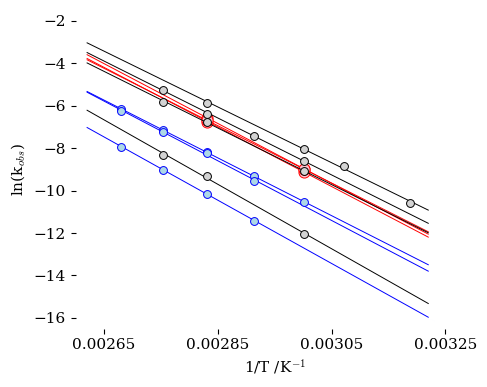

In [39]:
# pairs of substituent and concentration that had more than one temperature entry

substituent_list = list(concs.keys())  # All the substituents that have multiple concentrations with multiple temperatures
#substituent_list = ['H', 'p-Br', 'p-CH3', 'p-Cl', 'p-F', 'p-I', 'p-NO2', 'p-OCH3']  # The substituents used in the paper Table 1 and Table 2
#substituent_list = ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']  # The substituents used in the paper Table 1 only

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,4))  
ax.margins(x=.07, y=.07, tight=True)      # add 7% empty space around outside of plot area   

# make empty temporary lists to hold data for later
substituent_ = []
c_ = []
logA_ = []
Ea_ = []

# For each substituent and concentration, make an Arrhenius plot and do linear regression
for substituent in substituent_list:
    scs = list(set(concs[substituent]))  # get unique concentrations for given substituent in 'concs' dictionary
    for c in scs:

        df_temp = df.loc[(df['Substituent'] == substituent) & (df['%H2SO4'] == c), : ]  # filter dataframe for given substituent and concentration
#        print(substituent, c)       # print substituent and concentration
#        print(df_temp)              # print filtered dataframe

        # prepare x and y data for Arrhenius plot
        x = 1 / (df_temp['TempC'] + 273.15)       # x is 1/T
        y = np.log(df_temp['kobs']*1E-4)          # y is ln(k_obs)

        # plot data points according to rules below
        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:
            ax.scatter(x,y, s = 64, color="pink",  edgecolors = "red", zorder=2, linewidths=0.7)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']:
            ax.scatter(x,y, s = 32, color="lightgray",  edgecolors = "black", zorder=4, linewidths=0.7)
        else:
            ax.scatter(x,y, s = 32, color="lightblue",  edgecolors = "blue", zorder=2, linewidths=0.7)

        # perform linear regression and get slope, intercept, r_value, p_value, std_err
        results = stats.linregress(x, y)            # perform linear regression

        slope = results.slope                       # get slope and intercept
        intercept = results.intercept
        r_value = results.rvalue                    # correlation coefficient
        p_value = results.pvalue                    # p-value
        std_err = results.stderr                    # standard error of the slope
        intercept_stderr = results.intercept_stderr # standard error of the intercept

        slope_unc = unc.ufloat(slope, std_err)      # create uncertainties ufloat objects for slope and intercept
        intercept_unc = unc.ufloat(intercept, intercept_stderr)

#        print(f'slope: {slope_unc}, intercept: {intercept_unc}, r_value: {r_value}, std_err: {std_err}')

        # plot linear regression line
        x_fit = np.linspace(0.00262, 0.00322, 100)   # x values for fit line
#        x_fit = np.linspace(0, 0.00322, 100)
        y_fit = slope * x_fit + intercept            # y values for fit line

        # plot lines according to rules below
        if c == 98.2 and substituent in ['p-Br', 'p-I', 'p-F']:  
            ax.plot(x_fit, y_fit, '-', color='red', linewidth=0.7, zorder = 0)
        elif c == 98.2 and substituent in ['H', 'p-CH3', 'p-Cl', 'p-NO2', 'p-OCH3']:
            ax.plot(x_fit, y_fit, '-', color='black', linewidth=0.7, zorder = 3)
        else:
            ax.plot(x_fit, y_fit, '-', color='blue', linewidth=0.7, zorder = 0)
#        print()

        # calculate dH and dS from slope and intercept in erying plot
        R = 8.3140  # J/mol-K
        kB = 1.380649e-23  # J/K
        NA = 6.02214076e23  # 1/mol
        h = 6.62607015e-34  # J-s

        Ea_unc = -slope_unc * R / 1000 /4.1840 # kJ/mol
        A_unc = (intercept_unc)/np.log(10) # pre-exponential factor

        substituent_.append(substituent)  # add substituent to list
        c_.append(c)                      # add concentration to list
        Ea_.append(Ea_unc)                # add Ea and logA to lists
        logA_.append(A_unc)

#        print(f'For substituent {substituent} at %H2SO4 = {c}: Ea = {Ea_unc:.6f} kcal/mol, A = {A_unc:.6f}')
#        print('----------------------------------------')

# save collected data to CSV file
pd.DataFrame({                             # create dataframe from collected data
    'Substituent': substituent_,
    '%H2SO4': c_,
    'Ea (kcal/mol)': [ea.n for ea in Ea_],  # extract nominal values from each ufloat in Ea_ list
    'Ea std err': [ea.s for ea in Ea_],     # extract standard errors from each ufloat in Ea_ list
    'logA': [A.n for A in logA_],           # extract nominal values from each ufloat in logA_ list
    'logA std err': [A.s for A in logA_]    # extract standard errors from each ufloat in logA_ list
}).to_csv('output/Table_3_from_Fig_11_Arrhenius_Ea_logA.csv', index=False, header=True)   # save dataframe to CSV file

# finalize plot settings
ax.set_xlabel('1/T /K$^{-1}$')
ax.set_ylabel('ln(k$_{obs}$)')
ax.set_xlim(0.0026, 0.0033)
#ax.set_xlim(0, 0.0033)
ax.set_ylim(-16.5,-1.5)
ax.set_xticks([0.00265, 0.00285, 0.00305, 0.00325])
#ax.set_title(f'Substituent: {substituent}, %H$_2$SO$_4$ = {c}') 


plt.savefig('plots/Fig_11_ArrheniusPlot.pdf')  # save and show plot
plt.show()